<a href="https://colab.research.google.com/github/parth1rtx/SIH-2026/blob/main/dayinbits_week1_1.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
from google.colab import userdata
import os
os.environ["kaggleAPIkey"] = userdata.get("kaggleAPIkey")

In [ ]:
!pip install kaggle

In [ ]:
!kaggle datasets download -d jeanmidev/smart-meters-in-london


Dataset URL: https://www.kaggle.com/datasets/jeanmidev/smart-meters-in-london
License(s): ODbL-1.0
100% 1.17G/1.17G [00:11<00:00, 110MB/s]



In [ ]:
!unzip -q smart-meters-in-london.zip -d smart_meters_data


In [ ]:
import os
for f in os.listdir("smart_meters_data"):
    print(f)

hhblock_dataset
halfhourly_dataset
daily_dataset.csv
darksky_parameters_documentation.html
weather_hourly_darksky.csv
daily_dataset
acorn_details.csv
uk_bank_holidays.csv
weather_daily_darksky.csv
informations_households.csv


In [ ]:
import pandas as pd
df = pd.read_csv("smart_meters_data/informations_households.csv")
df.shape


(5566, 5)

In [11]:
#Day 2 - Data Explore and Household Pick

In [12]:
import pandas as pd
households = pd.read_csv("smart_meters_data/informations_households.csv")
households.head()

,LCLid,stdorToU,Acorn,Acorn_grouped,file
0,MAC005492,ToU,ACORN-,ACORN-,block_0
1,MAC001074,ToU,ACORN-,ACORN-,block_0
2,MAC000002,Std,ACORN-A,Affluent,block_0
3,MAC003613,Std,ACORN-A,Affluent,block_0
4,MAC003597,Std,ACORN-A,Affluent,block_0


In [13]:
households['file'].value_counts().head(20)

,count
file,
block_0,50
block_1,50
block_2,50
block_3,50
block_4,50
block_5,50
block_6,50
block_7,50
block_8,50


In [14]:
import os
os.listdir("smart_meters_data/halfhourly_dataset")

['halfhourly_dataset']

In [15]:
block_df = pd.read_csv("smart_meters_data/halfhourly_dataset/halfhourly_dataset/block_0.csv")
block_df.head()

,LCLid,tstp,energy(kWh/hh)
0,MAC000002,2012-10-12 00:30:00.0000000,0
1,MAC000002,2012-10-12 01:00:00.0000000,0
2,MAC000002,2012-10-12 01:30:00.0000000,0
3,MAC000002,2012-10-12 02:00:00.0000000,0
4,MAC000002,2012-10-12 02:30:00.0000000,0


In [16]:
block_df.isnull().sum()

,0
LCLid,0
tstp,0
energy(kWh/hh),0


In [17]:
block_df['LCLid'].nunique()

50

In [18]:
block_df['tstp'] = pd.to_datetime(block_df['tstp'])

In [19]:
block_df['energy(kWh/hh)'] = pd.to_numeric(block_df['energy(kWh/hh)'], errors='coerce')

In [24]:
counts = block_df.groupby('LCLid').size()
clean_households = counts[counts > 20000].index.tolist()  # households with plenty of readings
print(len(clean_households))
selected = clean_households[:25]

46


In [25]:
subset_df = block_df[block_df['LCLid'].isin(selected)]
subset_df.shape

(621260, 3)

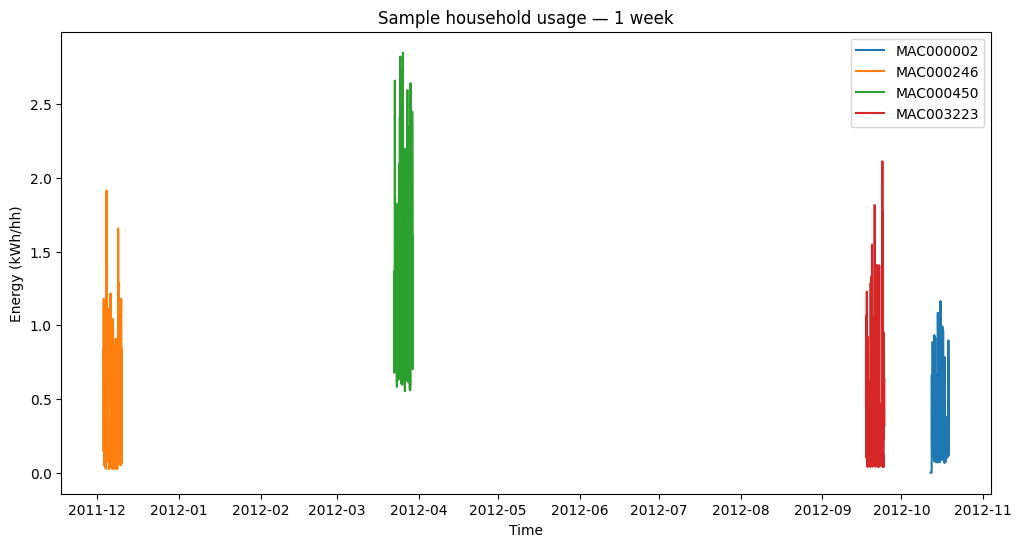

In [26]:
import matplotlib.pyplot as plt

sample_houses = selected[:4]
plt.figure(figsize=(12,6))
for h in sample_houses:
    house_data = subset_df[subset_df['LCLid'] == h].sort_values('tstp')
    plt.plot(house_data['tstp'][:336], house_data['energy(kWh/hh)'][:336], label=h)  # ~1 week of half-hourly data

plt.legend()
plt.xlabel("Time")
plt.ylabel("Energy (kWh/hh)")
plt.title("Sample household usage — 1 week")
plt.show()